# 03 — Baseline Model (Week 4)

**Goal:** train the first predictive model — a **Linear Regression** — on the cleaned
data from Week 3 and record its baseline performance.

Steps:
1. **Load** the cleaned CSV (`data/processed/sold_clean.csv`).
2. **Rebuild** the leakage-safe, time-based `build_train_test(X)` split from Week 3.
3. **Train** a Linear Regression (test = most recent month, train = X months before it).
4. **Evaluate** with R² (plus RMSE / MAE for context).
5. **Sweep X** — the training-window length is a tunable choice; pick the X with the best test R².
6. **Record** the baseline results and make a sample prediction.

> This is the reference point every later model (Week 5 trees, Week 7 boosting) is compared against.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Load the cleaned dataset

The cleaned CSV was saved *pre-split* in Week 3. CSV doesn't preserve dtypes, so we re-parse
`CloseDate` into a datetime and rebuild the `month_key` used by the time-based split.

In [2]:
CLEAN_PATH = "data/processed/sold_clean.csv"

data = pd.read_csv(CLEAN_PATH, low_memory=False)
data["CloseDate"] = pd.to_datetime(data["CloseDate"], errors="coerce")
data["month_key"] = data["CloseDate"].dt.to_period("M")

print(f"Loaded {len(data):,} rows x {data.shape[1]} cols")
data.head(3)

Loaded 319,311 rows x 23 cols


,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,GarageSpaces,Stories,FireplacesTotal,Latitude,Longitude,CountyOrParish,City,PostalCode,CloseDate,year_month,GarageSpaces_missing,Stories_missing,FireplacesTotal_missing,CountyOrParish_freq,City_freq,PostalCode_freq,month_key
0,815000.0,1974.0,4.0,4.0,NaN,2023.0,2.0,2.0,NaN,32.659315,-117.096922,San Diego,National City,91950,2024-01-05,202401,0,0,1,0.107829,0.000658,0.000658,2024-01
1,810000.0,1974.0,4.0,4.0,NaN,2023.0,2.0,2.0,NaN,32.659284,-117.097174,San Diego,National City,91950,2024-01-05,202401,0,0,1,0.107829,0.000658,0.000658,2024-01
2,2100000.0,3736.0,4.0,4.0,11219.0,2019.0,3.0,2.0,NaN,35.277199,-120.646786,San Luis Obispo,San Luis Obispo,93401,2024-01-02,202401,0,0,1,0.015975,0.002321,0.001484,2024-01


## 2. Rebuild the train/test split (from Week 3)

Same feature lists and leakage-safe split function as `02_preprocessing.ipynb`:
medians, frequency encoding, and the scaler are all fit on **train only**.

In [3]:
TARGET = "ClosePrice"

NUMERIC_FEATURES = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeSquareFeet", "YearBuilt", "GarageSpaces",
    "Stories", "FireplacesTotal", "Latitude", "Longitude",
]
CATEGORICAL_FEATURES = ["CountyOrParish", "City", "PostalCode"]

MODEL_NUMERIC = NUMERIC_FEATURES + [c for c in data.columns if c.endswith("_missing")]
MODEL_CATEGORICAL_ENC = [f"{c}_freq" for c in CATEGORICAL_FEATURES]

months = sorted(data["month_key"].dropna().unique())
print("Available months:", [str(m) for m in months])


def build_train_test(X, data=data, scale=True):
    """Leakage-safe time-based split. test = most recent month; train = X months before it."""
    test_month = months[-1]
    train_months = months[-(X + 1):-1]
    if len(train_months) < X:
        raise ValueError(f"Only {len(months)-1} months available before the test month; X={X} too large.")

    train = data[data.month_key.isin(train_months)].copy()
    test = data[data.month_key == test_month].copy()

    # Impute numeric medians from TRAIN only. Some features (e.g. FireplacesTotal) are
    # entirely missing in the most recent months, so their train median is NaN and fillna
    # is a no-op -> a final fillna(0) backstops those all-NaN columns. Their missingness is
    # already captured by the *_missing flag columns, so zero-filling loses no signal.
    medians = train[NUMERIC_FEATURES].median()
    train[NUMERIC_FEATURES] = train[NUMERIC_FEATURES].fillna(medians).fillna(0.0)
    test[NUMERIC_FEATURES] = test[NUMERIC_FEATURES].fillna(medians).fillna(0.0)

    # Frequency-encode categoricals from TRAIN only (unseen categories -> 0)
    for c in CATEGORICAL_FEATURES:
        freq = train[c].value_counts(normalize=True)
        train[f"{c}_freq"] = train[c].map(freq).fillna(0.0)
        test[f"{c}_freq"] = test[c].map(freq).fillna(0.0)

    feat_cols = MODEL_NUMERIC + MODEL_CATEGORICAL_ENC
    X_train_raw, X_test_raw = train[feat_cols], test[feat_cols]
    y_train, y_test = train[TARGET], test[TARGET]

    out = {"feature_cols": feat_cols,
           "X_train_raw": X_train_raw, "X_test_raw": X_test_raw,
           "y_train": y_train, "y_test": y_test,
           "test_month": str(test_month), "train_months": [str(m) for m in train_months]}

    if scale:
        scaler = StandardScaler().fit(X_train_raw)
        out["X_train"] = pd.DataFrame(scaler.transform(X_train_raw), columns=feat_cols, index=X_train_raw.index)
        out["X_test"] = pd.DataFrame(scaler.transform(X_test_raw), columns=feat_cols, index=X_test_raw.index)
        out["scaler"] = scaler
    return out

Available months: ['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05']


## 3. Train the baseline Linear Regression

Start with `X = 6` (six months of training data before the test month). Linear models need
standardized inputs, so we use the scaled feature matrices.

In [4]:
def evaluate(y_true, y_pred):
    return {
        "R2":   r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE":  mean_absolute_error(y_true, y_pred),
    }


split = build_train_test(X=6)
print("test month :", split["test_month"])
print("train months:", split["train_months"])
print(f"train rows : {len(split['y_train']):,}  |  test rows: {len(split['y_test']):,}")

lr = LinearRegression()
lr.fit(split["X_train"], split["y_train"])
pred = lr.predict(split["X_test"])

baseline = evaluate(split["y_test"], pred)
print("\nBaseline (Linear Regression, X=6):")
for k, v in baseline.items():
    print(f"  {k:5s}: {v:,.4f}" if k == "R2" else f"  {k:5s}: {v:,.0f}")

test month : 2026-05
train months: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
train rows : 59,169  |  test rows: 11,976

Baseline (Linear Regression, X=6):
  R2   : 0.4584
  RMSE : 1,035,140
  MAE  : 516,643


## 4. Sweep the training-window length X

The task doc says the training window `X` is **not fixed** — treat it as a tunable choice.
We fit a fresh Linear Regression for each X and compare **test R²** to pick the best window.

In [5]:
max_X = len(months) - 1
results = []
for X in range(1, max_X + 1):
    s = build_train_test(X=X)
    m = LinearRegression().fit(s["X_train"], s["y_train"])
    metrics = evaluate(s["y_test"], m.predict(s["X_test"]))
    results.append({"X": X, "train_rows": len(s["y_train"]), **metrics})

sweep = pd.DataFrame(results)
sweep

,X,train_rows,R2,RMSE,MAE
0,1,11977,0.450761,1.042420e+06,526408.181436
1,2,23118,0.455891,1.037540e+06,526394.261890
2,3,31622,0.457775,1.035742e+06,521491.653076
3,4,39073,0.457982,1.035544e+06,519017.956612
4,5,49472,0.458612,1.034943e+06,515317.271105
5,6,59169,0.458406,1.035140e+06,516642.901308
6,7,71148,0.459255,1.034327e+06,515124.770367
7,8,82568,0.459141,1.034436e+06,512456.329822
8,9,93978,0.458982,1.034589e+06,512373.144856
9,10,106056,0.459207,1.034373e+06,513114.082102


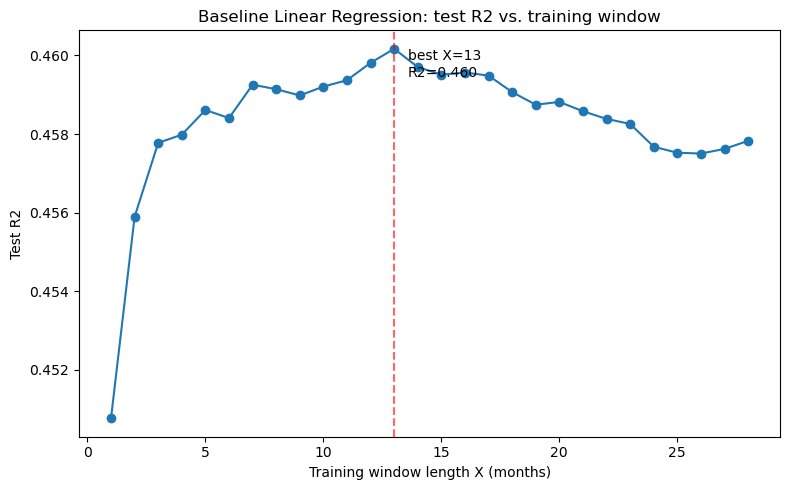

Best training window: X = 13  ->  test R2 = 0.4602


In [6]:
fig, ax = plt.subplots()
ax.plot(sweep["X"], sweep["R2"], marker="o")
best = sweep.loc[sweep["R2"].idxmax()]
ax.axvline(best["X"], color="red", ls="--", alpha=0.6)
ax.set_xlabel("Training window length X (months)")
ax.set_ylabel("Test R2")
ax.set_title("Baseline Linear Regression: test R2 vs. training window")
ax.annotate(f"best X={int(best['X'])}\nR2={best['R2']:.3f}",
            xy=(best["X"], best["R2"]), xytext=(10, -20),
            textcoords="offset points")
plt.tight_layout()
plt.show()

print(f"Best training window: X = {int(best['X'])}  ->  test R2 = {best['R2']:.4f}")

## 5. Refit at the best X and inspect coefficients

Refit at the winning window and look at which standardized features move price the most.

In [7]:
best_X = int(sweep.loc[sweep["R2"].idxmax(), "X"])
split = build_train_test(X=best_X)

lr = LinearRegression().fit(split["X_train"], split["y_train"])
pred = lr.predict(split["X_test"])
baseline = evaluate(split["y_test"], pred)

print(f"Baseline Linear Regression @ X={best_X}")
print(f"  test month : {split['test_month']}")
print(f"  R2   : {baseline['R2']:.4f}")
print(f"  RMSE : {baseline['RMSE']:,.0f}")
print(f"  MAE  : {baseline['MAE']:,.0f}")

coefs = (pd.Series(lr.coef_, index=split["feature_cols"])
           .sort_values(key=np.abs, ascending=False))
print("\nCoefficients (standardized features, biggest |effect| first):")
print(coefs.round(0))

Baseline Linear Regression @ X=13
  test month : 2026-05
  R2   : 0.4602
  RMSE : 1,033,452
  MAE  : 512,873

Coefficients (standardized features, biggest |effect| first):
LivingArea                 827641.0
BathroomsTotalInteger      332646.0
YearBuilt                 -246539.0
BedroomsTotal             -209741.0
PostalCode_freq           -173028.0
Latitude                  -130787.0
Stories_missing            124819.0
Stories                    -99305.0
GarageSpaces_missing        84173.0
Longitude                  -81162.0
LotSizeSquareFeet          -71431.0
CountyOrParish_freq        -49134.0
City_freq                   12139.0
GarageSpaces                -9593.0
FireplacesTotal                -0.0
FireplacesTotal_missing         0.0
dtype: float64


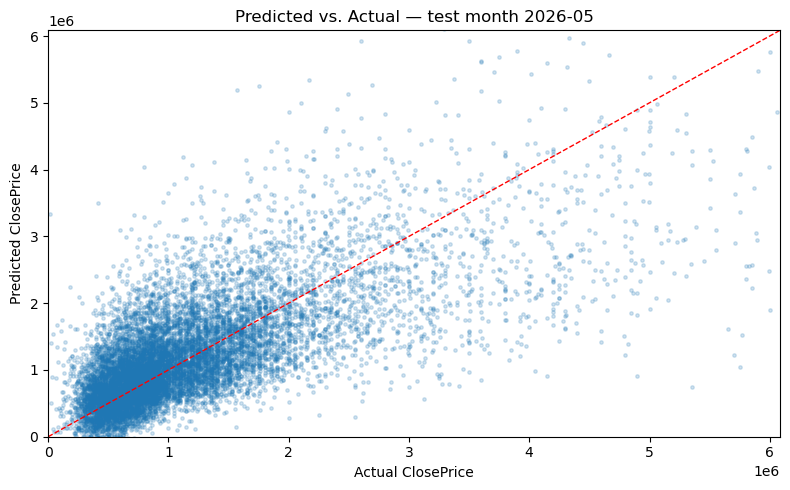

In [8]:
# Predicted vs. actual on the test month
fig, ax = plt.subplots()
ax.scatter(split["y_test"], pred, s=6, alpha=0.2)
lims = [0, split["y_test"].quantile(0.99)]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual ClosePrice"); ax.set_ylabel("Predicted ClosePrice")
ax.set_title(f"Predicted vs. Actual — test month {split['test_month']}")
plt.tight_layout()
plt.show()

## 6. Sample prediction

Predict the close price of one property (feed raw features through the same scaler).

In [9]:
sample_raw = split["X_test_raw"].iloc[[0]]
sample_scaled = pd.DataFrame(
    split["scaler"].transform(sample_raw), columns=split["feature_cols"], index=sample_raw.index)

pred_price = lr.predict(sample_scaled)[0]
actual_price = split["y_test"].loc[sample_raw.index[0]]
print(f"Predicted ClosePrice: ${pred_price:,.0f}")
print(f"Actual    ClosePrice: ${actual_price:,.0f}")

Predicted ClosePrice: $3,913,416
Actual    ClosePrice: $8,712,500


## 7. Record baseline results

Save the sweep table so later weeks can compare against the baseline number.

In [10]:
sweep.to_csv("data/processed/baseline_lr_sweep.csv", index=False)
print("Saved -> data/processed/baseline_lr_sweep.csv")

print("\n=== WEEK 4 BASELINE (Linear Regression) ===")
print(f"Best training window X : {best_X} months")
print(f"Test month             : {split['test_month']}")
print(f"Test R2                : {baseline['R2']:.4f}")
print(f"Test RMSE              : ${baseline['RMSE']:,.0f}")
print(f"Test MAE               : ${baseline['MAE']:,.0f}")

Saved -> data/processed/baseline_lr_sweep.csv

=== WEEK 4 BASELINE (Linear Regression) ===
Best training window X : 13 months
Test month             : 2026-05
Test R2                : 0.4602
Test RMSE              : $1,033,452
Test MAE               : $512,873
